In [5]:
!pip install POT
!pip install scikit-fuzzy

2025-06-13 14:49:56.340089: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


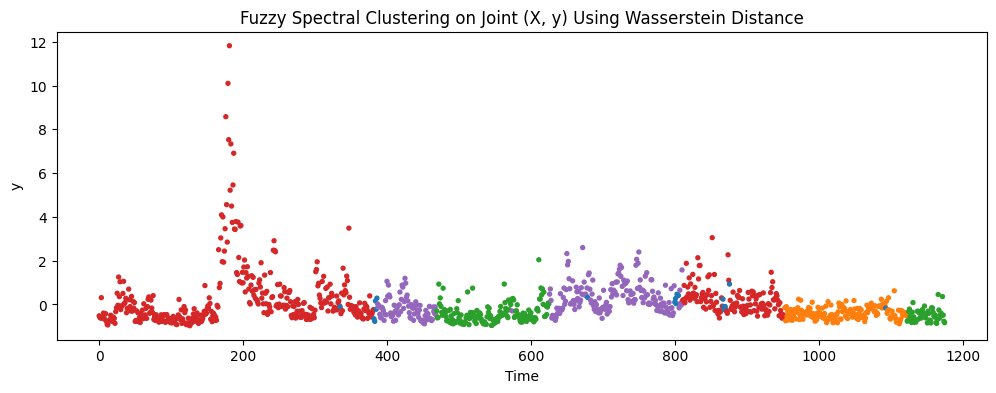

Time 177:  [0.15121107 0.181176   0.19151143 0.26088839 0.21521311]
Time 178:  [0.15121107 0.181176   0.19151143 0.26088839 0.21521311]
Time 179:  [0.15121107 0.181176   0.19151143 0.26088839 0.21521311]
Time 180:  [0.15121107 0.181176   0.19151143 0.26088839 0.21521311]
Time 181:  [0.15121107 0.181176   0.19151143 0.26088839 0.21521311]
Time 182:  [0.15121107 0.181176   0.19151143 0.26088839 0.21521311]
Time 183:  [0.15121107 0.181176   0.19151143 0.26088839 0.21521311]
Time 184:  [0.15121107 0.181176   0.19151143 0.26088839 0.21521311]
Time 185:  [0.15121107 0.181176   0.19151143 0.26088839 0.21521311]
Time 186:  [0.15121107 0.181176   0.19151143 0.26088839 0.21521311]
Time 187:  [0.15121107 0.181176   0.19151143 0.26088839 0.21521311]
Time 188:  [0.15121107 0.181176   0.19151143 0.26088839 0.21521311]
Time 189:  [0.15121107 0.181176   0.19151143 0.26088839 0.21521311]
Time 190:  [0.15121107 0.181176   0.19151143 0.26088839 0.21521311]
Time 191:  [0.15121107 0.181176   0.19151143 0.2

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import mood
from sklearn.cluster import SpectralClustering
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt

y = pd.read_csv("/work/y_scaled.csv", index_col=0)
X = pd.read_csv("/work/X.csv", index_col=0)
X_test = X[1176:]
y_test = y[1176:]
X = X[0:1176]
y = y[0:1176]
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

XY_combined = X.copy()
XY_combined["SPX"] = y

from sklearn.manifold import SpectralEmbedding
import skfuzzy as fuzz
import ot  # POT library for optimal transport

# Suppose y is (n_samples,), X is (n_samples, n_features)
# Both should be numpy arrays

# 1) Mood test segmentation on y
def mood_segmentation(y, window=5, alpha=0.05):
    change_points = []
    for t in range(window, len(y) - window):
        left = y[t - window:t]
        right = y[t:t + window]
        stat, p = mood(left, right)
        if p < alpha:
            change_points.append(t)
    return sorted(set(change_points))

change_points = mood_segmentation(y)
change_points = [0] + change_points + [len(y)]

# 2) Split joint data into segments
segments = [np.hstack((X[change_points[i]:change_points[i+1]], 
                       np.array(y[change_points[i]:change_points[i+1]]).reshape(-1,1)))
            for i in range(len(change_points) - 1)]

# 3) Compute pairwise Wasserstein distances between segments using POT
def segment_wasserstein(seg1, seg2):
    n1 = seg1.shape[0]
    n2 = seg2.shape[0]
    a, b = np.ones((n1,)) / n1, np.ones((n2,)) / n2
    M = ot.dist(seg1, seg2, metric='euclidean')
    W = ot.emd2(a, b, M)  # squared Wasserstein distance
    return np.sqrt(W)

n_segments = len(segments)
W_dist = np.zeros((n_segments, n_segments))

for i in range(n_segments):
    for j in range(i+1, n_segments):
        dist = segment_wasserstein(segments[i], segments[j])
        W_dist[i, j] = W_dist[j, i] = dist

# 4) Convert distances to similarity matrix
sigma = np.median(W_dist[W_dist > 0])
W_sim = np.exp(-W_dist**2 / (2 * sigma**2))

# 5) Spectral embedding (no clustering yet)
n_clusters = 5
embedding = SpectralEmbedding(n_components=n_clusters, affinity='precomputed', random_state=0)
U = embedding.fit_transform(W_sim)  # shape (n_segments, n_clusters)

# Optional: normalize rows
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)

# 6) Fuzzy clustering with scikit-fuzzy
# Transpose required: shape must be (features, samples)
U_T = U_norm.T  # shape: (features, n_segments)

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    U_T,            # data (features x samples)
    c=n_clusters,   # number of clusters
    m=2.0,          # fuzziness coefficient
    error=1e-5,
    maxiter=1000,
    init=None,
    seed=0
)

# u is (n_clusters, n_segments)
# Convert to (n_segments, n_clusters)
membership_probs = u.T
fuzzy_labels = np.argmax(membership_probs, axis=1)

# 7) Assign fuzzy memberships back to each point in y
# We'll store a (len(y), n_clusters) array of probabilities
point_membership_probs = np.zeros((len(y), n_clusters))

for i in range(n_segments):
    start = change_points[i]
    end = change_points[i+1]
    for k in range(n_clusters):
        point_membership_probs[start:end, k] = membership_probs[i, k]

# Optional: use hard labels for visualization
point_hard_labels = np.argmax(point_membership_probs, axis=1)

# 8) Visualize
colors = plt.cm.tab10(point_hard_labels % 10)
plt.figure(figsize=(12, 4))
plt.scatter(range(len(y)), y, c=colors, s=8)
plt.title("Fuzzy Spectral Clustering on Joint (X, y) Using Wasserstein Distance")
plt.xlabel("Time")
plt.ylabel("y")
plt.show()

for t in range(len(y)):
    print(f"Time {t}: ", point_membership_probs[t])

In [9]:
!pip install --upgrade pip setuptools wheel
!pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0 xgboost==1.7.5 scikit-fuzzy pot
import sklearn
import xgboost
import imblearn
import skfuzzy
import ot

print("scikit-learn version:", sklearn.__version__)
print("xgboost version:", xgboost.__version__)
print("imbalanced-learn version:", imblearn.__version__)


scikit-learn version: 1.3.2
xgboost version: 1.7.5
imbalanced-learn version: 0.11.0


Fitting 3 folds for each of 10 candidates, totalling 30 fits
/root/venv/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/root/venv/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/root/venv/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
Accuracy: 0.9534


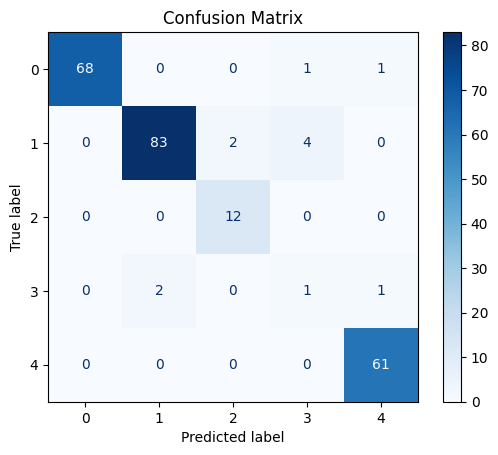

In [18]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split

# Load the data
y = pd.read_csv("/work/cluster_labels_1.csv")
X = pd.read_csv("/work/X.csv", index_col=0)

# Split the data
X_test = X[1176:]
y_test = y[1176:]
X = X[0:1176]
y = y[0:1176]

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# XGBoost classifier
xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Reduce search space
param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Train
random_search.fit(X_train, y_train)

# Predict and evaluate
y_pred = random_search.best_estimator_.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()